# Notebook 02 — Monte Carlo Exposure Simulation

This notebook computes the **CCR exposure profile** for a portfolio of derivatives via Monte Carlo simulation.

## Metrics

| Metric | Formula | Regulatory use |
|---|---|---|
| **EE(t)** | E[max(V(t), 0)] | Building block |
| **PFE(t)** | Quantile_95% of max(V(t),0) | Credit limit management |
| **EPE** | avg over [0,T] of EE | IMM input |
| **EEPE** | Running-max EPE over [0,1y] | **IMM capital (Basel III)** |
| **EAD** | 1.4 × EEPE | RWA input |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from ccr.instruments import IRSwap, FXForward, EquityOption
from ccr.simulation import HullWhite1F, GBM, simulate_correlated
from ccr.exposure import ExposureProfile, NettingSet

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

N_PATHS  = 3000
N_STEPS  = 120
HORIZON  = 10.0
SEED     = 42

time_grid = np.linspace(0, HORIZON, N_STEPS + 1)
print(f'Setup: {N_PATHS} paths × {N_STEPS+1} time steps, horizon={HORIZON}y')

Setup: 3000 paths × 121 time steps, horizon=10.0y


## 1. IRS Exposure under Hull-White

A 10-year payer IRS exposed to Hull-White rate dynamics (mean-reverting short rate).

Key observation: EE starts low (no volatility has accumulated), peaks at mid-life (**exposure hump**), then declines as remaining cash flows decrease. This hump is characteristic of IRS — it results from the trade-off between growing rate uncertainty and shrinking remaining tenor.

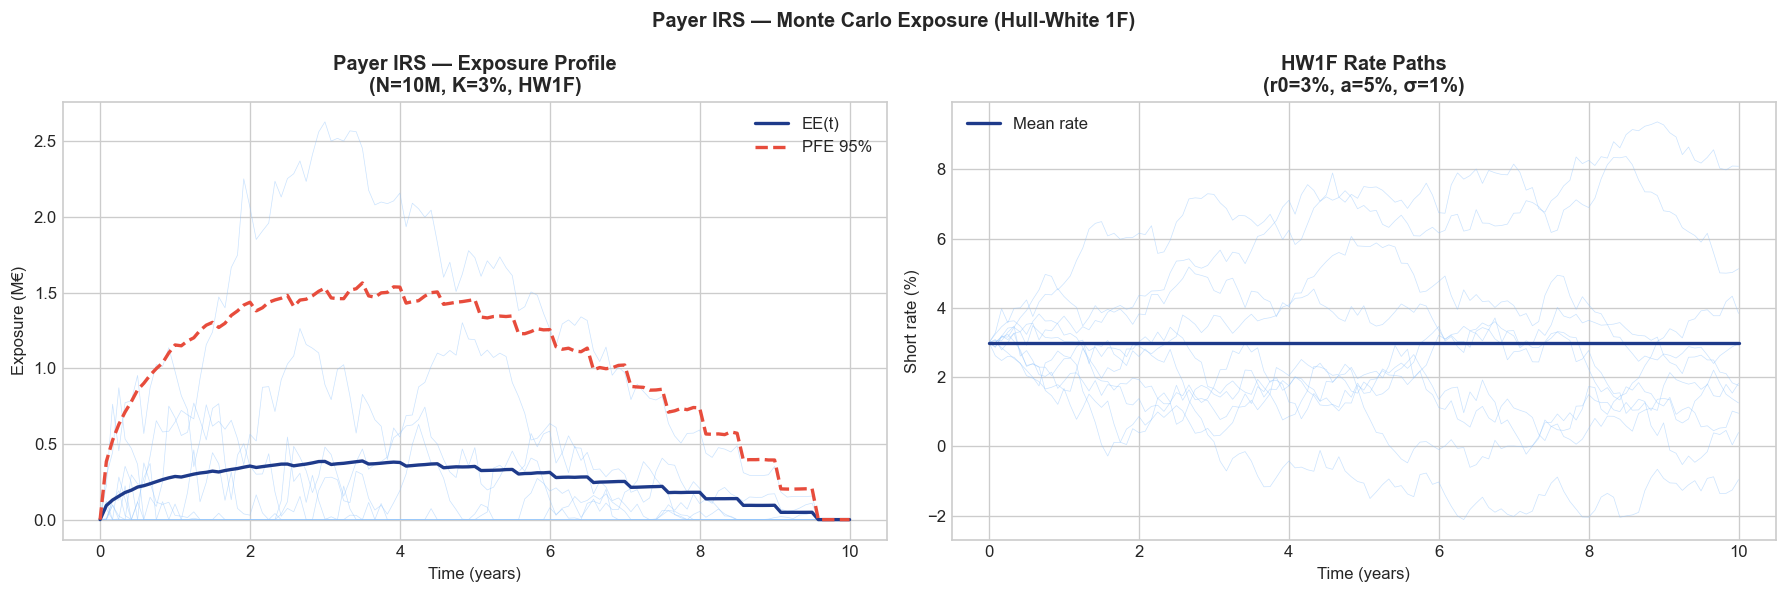


--- IRS Exposure Metrics ---
  EPE         :      196,850
  EEPE        :      208,737
  EAD_IMM     :      292,232
  MaxPFE      :    1,564,816
  MaxEE       :      387,642
  n_paths     :        3,000


In [2]:
# Hull-White 1F rate simulation
hw = HullWhite1F(r0=0.03, a=0.05, sigma=0.010)
sim_rates = hw.simulate(n_paths=N_PATHS, n_steps=N_STEPS, horizon=HORIZON, seed=SEED)

# IRS MtM profile
irs_payer = IRSwap(notional=10_000_000, fixed_rate=0.03, maturity=HORIZON, position='payer')
mtm_irs   = irs_payer.mtm_profile(sim_rates.paths, time_grid)

profile_irs = ExposureProfile(mtm_irs, time_grid, pfe_quantile=0.95)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Selected paths + EE
for i in range(0, min(50, N_PATHS), 5):
    axes[0].plot(time_grid, np.maximum(mtm_irs[i], 0) / 1e6, color='#93c5fd', lw=0.4, alpha=0.5)

axes[0].plot(time_grid, profile_irs.ee() / 1e6, color='#1e3a8a', lw=2.0, label='EE(t)')
axes[0].plot(time_grid, profile_irs.pfe() / 1e6, color='#e74c3c', lw=2.0, ls='--', label='PFE 95%')
axes[0].set_xlabel('Time (years)'); axes[0].set_ylabel('Exposure (M€)')
axes[0].set_title('Payer IRS — Exposure Profile\n(N=10M, K=3%, HW1F)', fontweight='bold')
axes[0].legend()

# Rate paths
for i in range(0, 100, 10):
    axes[1].plot(time_grid, sim_rates.paths[i] * 100, color='#93c5fd', lw=0.4, alpha=0.5)
axes[1].plot(time_grid, sim_rates.mean() * 100, color='#1e3a8a', lw=2.0, label='Mean rate')
axes[1].set_xlabel('Time (years)'); axes[1].set_ylabel('Short rate (%)')
axes[1].set_title('HW1F Rate Paths\n(r0=3%, a=5%, σ=1%)', fontweight='bold')
axes[1].legend()

plt.suptitle('Payer IRS — Monte Carlo Exposure (Hull-White 1F)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

m = profile_irs.scalar_metrics(capital_horizon=1.0)
print('\n--- IRS Exposure Metrics ---')
for k, v in m.items():
    print(f'  {k:<12}: {v:>12,.0f}')

## 2. FX Forward Exposure under GBM

FX forward exposure **grows monotonically** with time (unlike IRS) — there is no hump because there is only one cash flow at maturity. PFE grows as √T (diffusion of the spot).

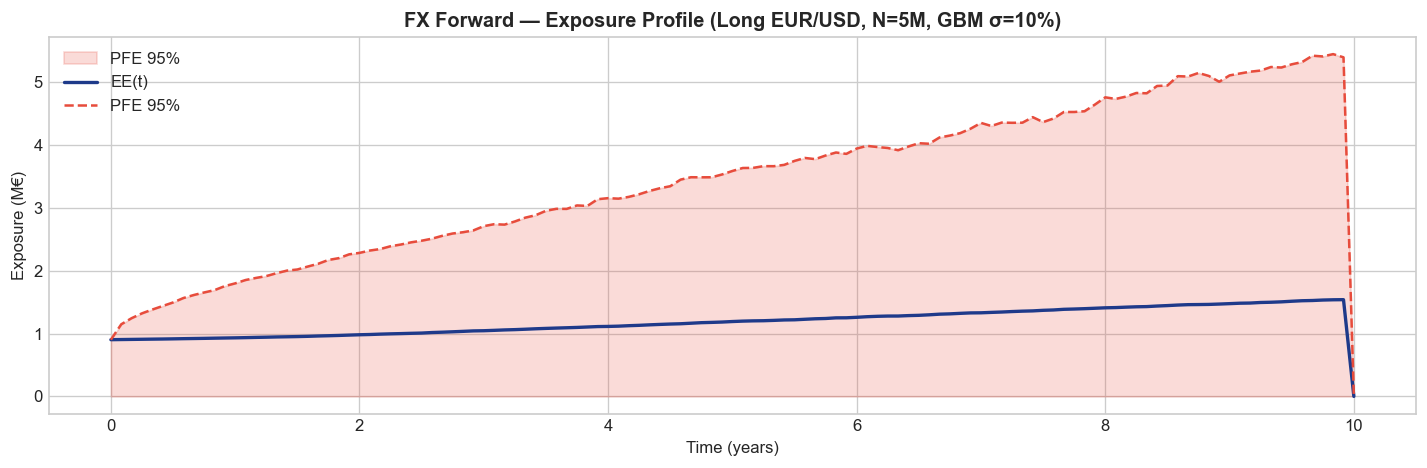

In [3]:
gbm_fx = GBM(S0=1.10, mu=0.02, sigma=0.10)
sim_fx = gbm_fx.simulate(n_paths=N_PATHS, n_steps=N_STEPS, horizon=HORIZON, seed=SEED)

fwd = FXForward(notional_foreign=5_000_000, forward_rate_agreed=1.10, maturity=HORIZON, position='long')
mtm_fx = fwd.mtm_profile(sim_fx.paths, rd=0.03, rf=0.01, time_grid=time_grid)

profile_fx = ExposureProfile(mtm_fx, time_grid, pfe_quantile=0.95)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_grid, profile_fx.pfe() / 1e6, alpha=0.2, color='#e74c3c', label='PFE 95%')
ax.plot(time_grid, profile_fx.ee()  / 1e6, color='#1e3a8a', lw=2.0, label='EE(t)')
ax.plot(time_grid, profile_fx.pfe() / 1e6, color='#e74c3c', lw=1.5, ls='--', label='PFE 95%')
ax.set_xlabel('Time (years)'); ax.set_ylabel('Exposure (M€)')
ax.set_title('FX Forward — Exposure Profile (Long EUR/USD, N=5M, GBM σ=10%)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Netting benefit — portfolio level

When a payer IRS and a receiver IRS are in the same netting set, their exposures offset. This illustrates the fundamental benefit of ISDA netting: the legal right to net MtM values on default reduces CCR exposure dramatically.

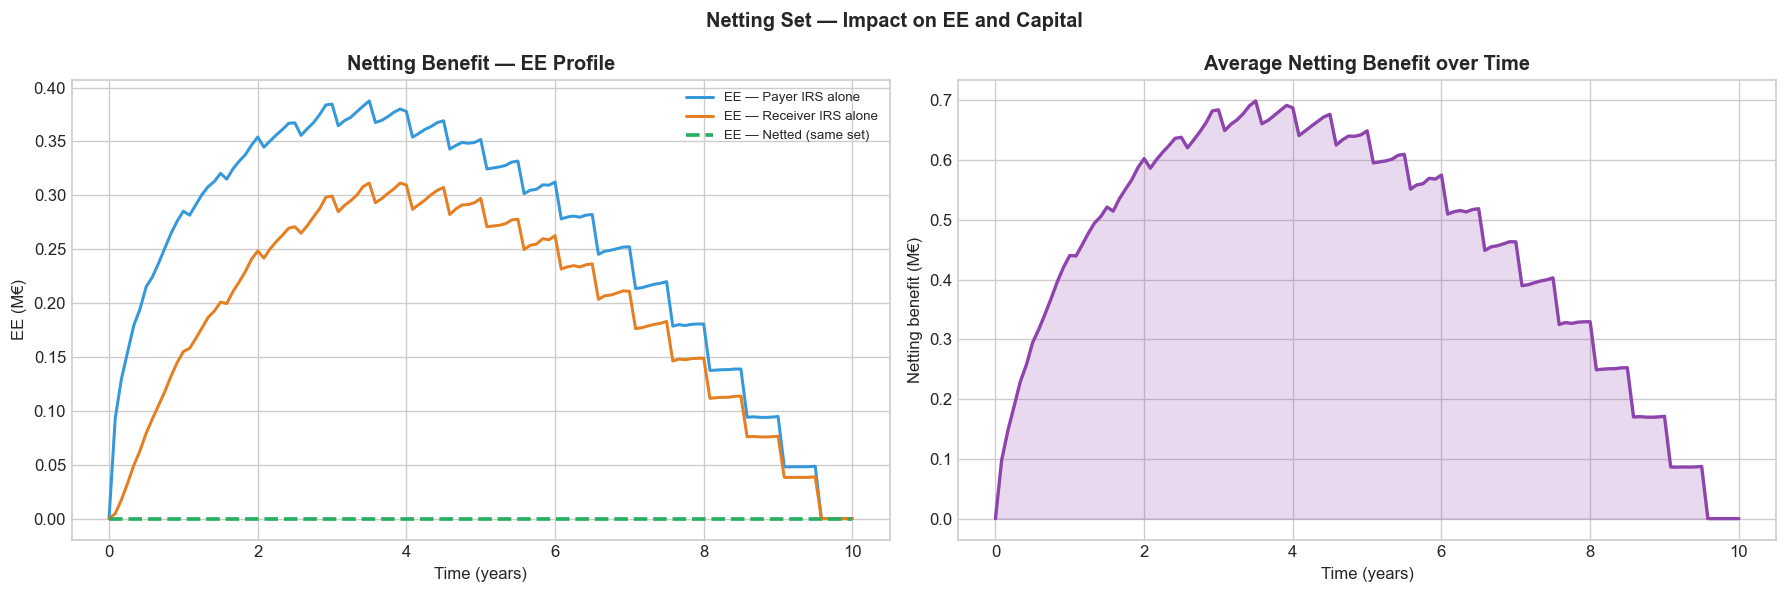


EEPE (payer alone):    208.7 k€
EEPE (netted):           0.0 k€
Netting benefit:       100.0%  reduction in EEPE


In [4]:
irs_receiver = IRSwap(notional=10_000_000, fixed_rate=0.025, maturity=HORIZON, position='receiver')
mtm_recv = irs_receiver.mtm_profile(sim_rates.paths, time_grid)

# Netting set: payer + receiver
ns = NettingSet(name='IRS_netting_set', trades=[mtm_irs, mtm_recv], apply_netting=True)
net_mtm = ns.net_mtm()

profile_gross_payer  = ExposureProfile(mtm_irs,  time_grid)
profile_gross_recv   = ExposureProfile(mtm_recv, time_grid)
profile_netted       = ExposureProfile(net_mtm,  time_grid)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(time_grid, profile_gross_payer.ee() / 1e6, label='EE — Payer IRS alone', color='#3498db', lw=1.8)
axes[0].plot(time_grid, profile_gross_recv.ee()  / 1e6, label='EE — Receiver IRS alone', color='#e67e22', lw=1.8)
axes[0].plot(time_grid, profile_netted.ee()       / 1e6, label='EE — Netted (same set)', color='#27ae60', lw=2.2, ls='--')
axes[0].set_title('Netting Benefit — EE Profile', fontweight='bold')
axes[0].set_xlabel('Time (years)'); axes[0].set_ylabel('EE (M€)')
axes[0].legend(fontsize=8)

benefit = ns.netting_benefit()
axes[1].plot(time_grid, benefit.mean(axis=0) / 1e6, color='#8e44ad', lw=2.0)
axes[1].fill_between(time_grid, benefit.mean(axis=0) / 1e6, alpha=0.2, color='#8e44ad')
axes[1].set_title('Average Netting Benefit over Time', fontweight='bold')
axes[1].set_xlabel('Time (years)'); axes[1].set_ylabel('Netting benefit (M€)')

plt.suptitle('Netting Set — Impact on EE and Capital', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nEEPE (payer alone): {profile_gross_payer.eepe()/1e3:>8.1f} k€')
print(f'EEPE (netted):      {profile_netted.eepe()/1e3:>8.1f} k€')
pct = (1 - profile_netted.eepe() / profile_gross_payer.eepe()) * 100
print(f'Netting benefit:    {pct:>8.1f}%  reduction in EEPE')

## 4. Correlated multi-factor portfolio

Real portfolios contain **correlated** instruments. A negative correlation between rates and FX (common: USD rates rise → EUR/USD falls) changes the shape of the aggregate exposure.

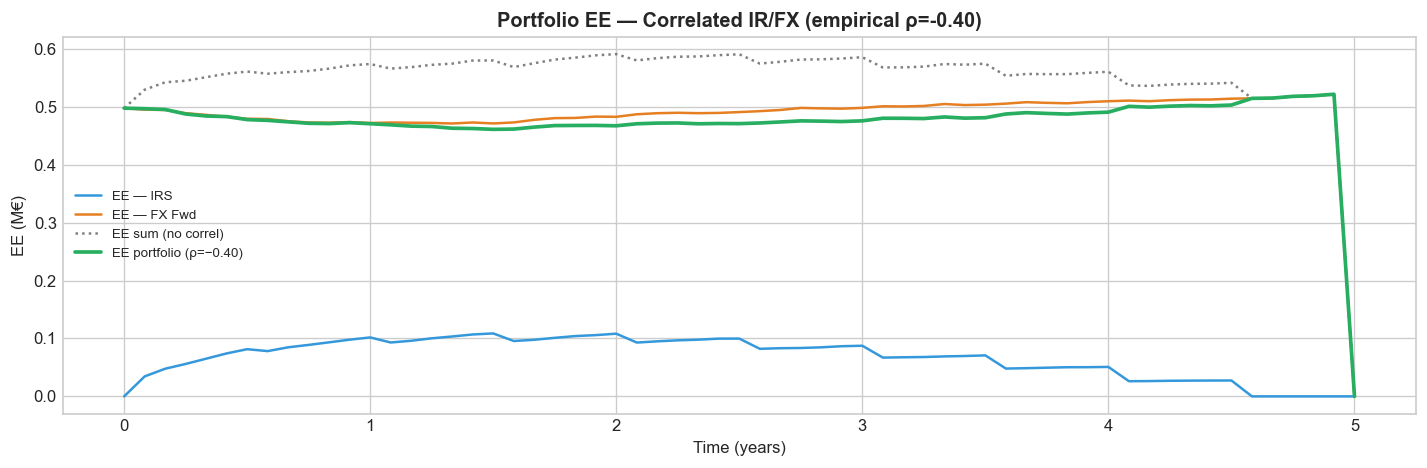

In [5]:
# Correlated simulation: IR (HW1F) and FX (GBM) with ρ = -0.40
from ccr.simulation import HullWhite1F, GBM

corr_matrix = np.array([[1.0, -0.40],
                         [-0.40, 1.0]])

hw_model  = HullWhite1F(r0=0.03, a=0.05, sigma=0.010)
gbm_model = GBM(S0=1.10, mu=0.02, sigma=0.10)

sims = simulate_correlated(
    models=[hw_model, gbm_model],
    correlation_matrix=corr_matrix,
    n_paths=N_PATHS, n_steps=N_STEPS, horizon=5.0, seed=SEED,
)

rate_sim_corr = sims[0]
fx_sim_corr   = sims[1]

# Check empirical correlation
r_returns  = np.diff(rate_sim_corr.paths[:, :51], axis=1).flatten()
fx_returns = np.diff(np.log(fx_sim_corr.paths[:, :51]), axis=1).flatten()
emp_corr = np.corrcoef(r_returns, fx_returns)[0, 1]

# MtM on correlated paths
tg5 = np.linspace(0, 5.0, 61)
irs5 = IRSwap(notional=10_000_000, fixed_rate=0.03, maturity=5.0, position='payer')
fwd5 = FXForward(notional_foreign=5_000_000, forward_rate_agreed=1.10, maturity=5.0, position='long')

mtm_irs_corr = irs5.mtm_profile(rate_sim_corr.paths[:, :61], tg5)
mtm_fx_corr  = fwd5.mtm_profile(fx_sim_corr.paths[:, :61], 0.03, 0.01, tg5)

profile_irs_c  = ExposureProfile(mtm_irs_corr, tg5)
profile_fx_c   = ExposureProfile(mtm_fx_corr, tg5)
profile_port_c = ExposureProfile(mtm_irs_corr + mtm_fx_corr, tg5)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tg5, profile_irs_c.ee()  / 1e6, label='EE — IRS',       color='#3498db', lw=1.5)
ax.plot(tg5, profile_fx_c.ee()   / 1e6, label='EE — FX Fwd',    color='#e67e22', lw=1.5)
ax.plot(tg5, (profile_irs_c.ee() + profile_fx_c.ee()) / 1e6,
        label='EE sum (no correl)', color='grey', lw=1.5, ls=':')
ax.plot(tg5, profile_port_c.ee() / 1e6, label='EE portfolio (ρ=−0.40)', color='#27ae60', lw=2.2)
ax.set_xlabel('Time (years)'); ax.set_ylabel('EE (M€)')
ax.set_title(f'Portfolio EE — Correlated IR/FX (empirical ρ={emp_corr:.2f})', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()